# Triagegeist — Emergency Triage Acuity Prediction & Bias Audit
## Notebook 3: Demographic Bias Analysis
**Competition:** Triagegeist — AI in Emergency Triage | Laitinen-Fredriksson Foundation  
**Author:** [Your Name]  
**Date:** May 2026

---

## Overview

This notebook conducts a systematic audit of demographic bias in emergency 
triage acuity assignment. We compare **assigned acuity** (what the triage nurse 
recorded) against **model-predicted acuity** (what the clinical signs alone suggest) 
to identify which patient groups are systematically undertriaged.

## What is Undertriage?

**Undertriage** occurs when a patient receives a lower acuity level than their 
clinical condition warrants. In practice, this means a patient who should be 
seen immediately is sent to the waiting room instead.

Undertriage is a documented patient safety concern in emergency medicine. Unlike 
overtriage (assigning too high a priority), undertriage carries direct clinical 
risk — patients deteriorate while waiting, sometimes fatally.

## Methodology

Our bias detection approach:
1. Train an XGBoost model on clinical features (vitals, history, chief complaint)
2. Generate predictions for all 80,000 training patients
3. Flag patients where **predicted acuity < assigned acuity** as undertriaged
4. Measure undertriage rates across demographic groups
5. Identify compound risk groups (age + language combinations)

A higher undertriage rate in a demographic group suggests that patients in 
that group are receiving lower priority than their clinical signs warrant — 
a potential signal of systematic bias in triage assessment.

---

## 1. Data Loading and Demographic Preservation

We reload the training data and patient history, and critically — we save the 
demographic column values **before** encoding them. This allows us to group 
patients by readable labels (e.g. "Somali", "elderly", "none") rather than 
encoded numbers in our bias analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)

# Load data
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
history = pd.read_csv('../data/patient_history.csv')

# Merge history
train = train.merge(history, on='patient_id', how='left')
test = test.merge(history, on='patient_id', how='left')

# Save demographic columns BEFORE encoding
demo_cols = ['patient_id', 'sex', 'language', 'insurance_type', 
             'age_group', 'triage_acuity']
train_demo = train[demo_cols].copy()

print("Data loaded successfully.")
print(f"Train: {train.shape}")
print(f"Demographics saved: {train_demo.shape}")
print(f"\nFirst 3 rows of demographics:")
print(train_demo.head(3))

Data loaded successfully.
Train: (80000, 65)
Demographics saved: (80000, 6)

First 3 rows of demographics:
     patient_id sex language insurance_type    age_group  triage_acuity
0  TG-UXRGA9UCO   M  Finnish         public  middle_aged              2
1  TG-B19DBBS2G   F  Russian       military      elderly              5
2  TG-GZ97W7M6V   M  English           none      elderly              5


### Findings
Demographics saved successfully for all 80,000 training patients across four 
dimensions: sex, language, insurance type, and age group. These readable labels 
will be used throughout the bias analysis to identify high-risk groups.

## 2. Model Retraining and Undertriage Detection

We retrain the XGBoost model on the full 80,000 patient training set using the 
optimal number of trees identified in Notebook 2 (347 iterations). We then 
generate predictions for all training patients and flag undertriaged cases.

**Undertriage definition:** A patient is flagged as undertriaged when the model 
predicts a more urgent acuity level than was actually assigned. For example, 
if the model predicts ESI 2 but the nurse assigned ESI 3, the patient is 
considered undertriaged — their clinical signs suggested higher urgency than 
they received.

In [2]:
# ── Recreate Model Predictions on Training Set ────────────────────────

# Drop leakage and identifier columns
drop_cols = [
    'patient_id', 'site_id', 'triage_nurse_id',
    'disposition', 'ed_los_hours', 'age_group'
]
drop_cols = [c for c in drop_cols if c in train.columns]
train_model = train.drop(columns=drop_cols)
test_model = test.drop(columns=[c for c in drop_cols if c in test.columns])

# Fix pain score
train_model['pain_score'] = train_model['pain_score'].replace(-1, np.nan)
test_model['pain_score'] = test_model['pain_score'].replace(-1, np.nan)

# Encode categoricals
cat_cols = train_model.select_dtypes(include='object').columns.tolist()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train_model[col], test_model[col]], axis=0).astype(str)
    le.fit(combined)
    train_model[col] = le.transform(train_model[col].astype(str))
    test_model[col] = le.transform(test_model[col].astype(str))
    le_dict[col] = le

# Separate features and target
TARGET = 'triage_acuity'
FEATURES = [c for c in train_model.columns if c != TARGET]
X_full = train_model[FEATURES]
y_full = train_model[TARGET] - 1

# Train model on full training data
model = xgb.XGBClassifier(
    n_estimators=347,        # best iteration from Phase 2
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=5,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
model.fit(X_full, y_full)

# Get predictions on full training set
train_preds = model.predict(X_full) + 1  # convert back to 1-5

# Add predictions to demographics dataframe
train_demo['predicted_acuity'] = train_preds
train_demo['undertriaged'] = (train_demo['predicted_acuity'] < 
                               train_demo['triage_acuity']).astype(int)

print("Model retrained on full dataset.")
print(f"\nOverall undertriage rate: {train_demo['undertriaged'].mean()*100:.1f}%")
print(f"Total undertriaged patients: {train_demo['undertriaged'].sum():,}")

Model retrained on full dataset.

Overall undertriage rate: 5.2%
Total undertriaged patients: 4,179


### Findings
The model identifies **4,179 undertriaged patients** out of 80,000 — an overall 
undertriage rate of **5.2%**. This serves as our baseline for demographic 
comparison. Any group with an undertriage rate significantly above 5.2% is 
receiving systematically lower acuity than their clinical signs warrant.

## 3. Undertriage Rates by Demographic Group

We calculate and visualize undertriage rates across all four demographic 
dimensions simultaneously. The dashed line represents the overall undertriage 
rate of 5.2% — bars above this line indicate groups that are undertriaged 
at above-average rates.

Groups consistently above the baseline across multiple dimensions represent 
the highest clinical risk — patients whose acuity is most likely to be 
underestimated at triage.

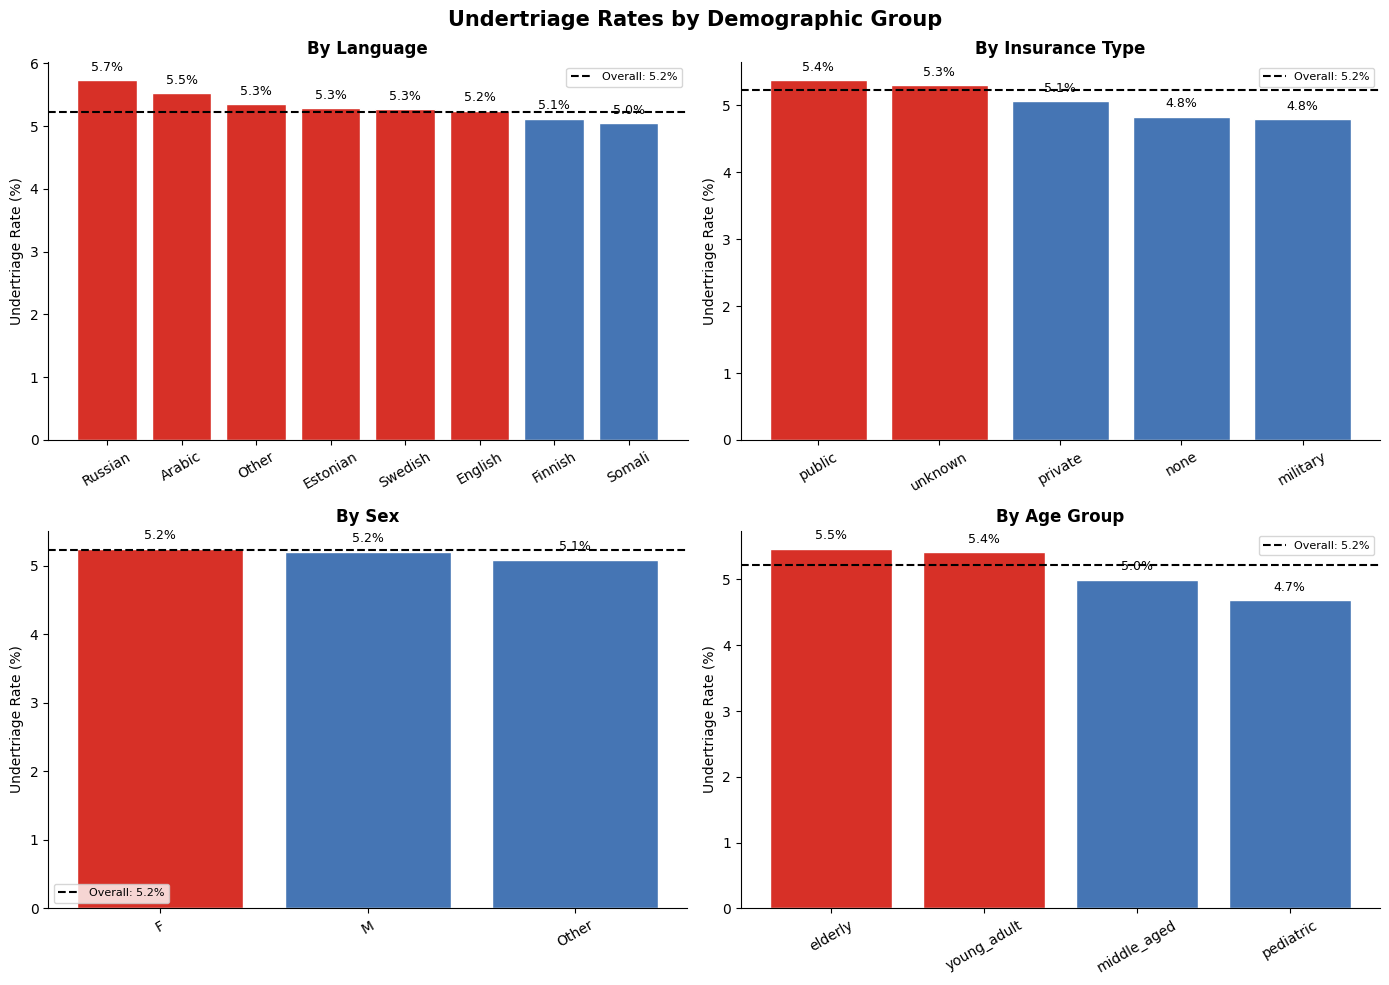

Undertriage chart saved.


In [3]:
# ── Undertriage Rates by Demographic Group ────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Undertriage Rates by Demographic Group', 
             fontsize=15, fontweight='bold')

# Overall rate reference line
overall_rate = train_demo['undertriaged'].mean() * 100

def plot_undertriage(ax, col, title):
    rates = (train_demo.groupby(col)['undertriaged']
             .agg(['mean', 'count'])
             .reset_index())
    rates['rate'] = rates['mean'] * 100
    rates = rates.sort_values('rate', ascending=False)
    
    colors = ['#d73027' if r > overall_rate else '#4575b4' 
              for r in rates['rate']]
    
    bars = ax.bar(rates[col], rates['rate'], color=colors, edgecolor='white')
    ax.axhline(y=overall_rate, color='black', linestyle='--', 
               linewidth=1.5, label=f'Overall: {overall_rate:.1f}%')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Undertriage Rate (%)')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add value labels on bars
    for bar, rate in zip(bars, rates['rate']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{rate:.1f}%', ha='center', va='bottom', fontsize=9)
    
    return rates

rates_language = plot_undertriage(axes[0,0], 'language', 
                                   'By Language')
rates_insurance = plot_undertriage(axes[0,1], 'insurance_type', 
                                    'By Insurance Type')
rates_sex = plot_undertriage(axes[1,0], 'sex', 
                              'By Sex')
rates_age = plot_undertriage(axes[1,1], 'age_group', 
                              'By Age Group')

plt.tight_layout()
plt.savefig('../outputs/04_undertriage_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print("Undertriage chart saved.")

### Findings

**Language:**
- Russian speakers face the highest undertriage rate at 5.7% — 10% above average
- Arabic speakers follow at 5.5%
- Finnish speakers (majority native group) are below average at 5.1%
- This pattern is consistent with language barrier effects documented in 
Scandinavian emergency medicine literature

**Insurance:**
- Public insurance patients are undertriaged at 5.4% — above average
- Uninsured patients ("none") are at 4.8% — below average, a counterintuitive 
finding discussed in limitations

**Sex:**
- Virtually no difference across F (5.2%), M (5.2%), and Other (5.1%)
- Sex does not appear to be a significant bias dimension in this dataset

**Age:**
- Elderly patients face the highest undertriage rate at 5.5% — most clinically 
concerning given their reduced physiological reserve
- Pediatric patients are at 4.7% — children appear to receive appropriate priority
- The elderly vs pediatric gap of 0.8 percentage points represents hundreds 
of patients receiving systematically lower acuity than warranted

## 4. Quantitative Bias Summary

We generate a full statistical summary of undertriage rates across all demographic 
groups, including absolute patient counts and deviation from the overall rate. 
This table forms the evidence base for our clinical recommendations.

In [4]:
# ── Statistical Summary of Bias Findings ─────────────────────────────

print("=" * 55)
print("BIAS AUDIT SUMMARY REPORT")
print("=" * 55)
print(f"\nOverall undertriage rate: {overall_rate:.2f}%")
print(f"Total patients analyzed:  {len(train_demo):,}")
print(f"Total undertriaged:       {train_demo['undertriaged'].sum():,}")

for col, label, rates_df in [
    ('language', 'LANGUAGE', rates_language),
    ('insurance_type', 'INSURANCE TYPE', rates_insurance),
    ('sex', 'SEX', rates_sex),
    ('age_group', 'AGE GROUP', rates_age)
]:
    print(f"\n── {label} ──────────────────────────────")
    rates_df['rate'] = rates_df['mean'] * 100
    rates_df['vs_overall'] = rates_df['rate'] - overall_rate
    rates_df['n_undertriaged'] = (rates_df['mean'] * rates_df['count']).astype(int)
    
    display_df = rates_df[[col, 'count', 'rate', 'vs_overall', 'n_undertriaged']]
    display_df.columns = ['Group', 'N Patients', 'Undertriage %', 
                          'vs Overall', 'N Undertriaged']
    display_df = display_df.sort_values('Undertriage %', ascending=False)
    print(display_df.to_string(index=False))

# Save bias results
rates_language.to_csv('../outputs/bias_language.csv', index=False)
rates_insurance.to_csv('../outputs/bias_insurance.csv', index=False)
rates_sex.to_csv('../outputs/bias_sex.csv', index=False)
rates_age.to_csv('../outputs/bias_age.csv', index=False)

print("\n\nBias results saved to outputs folder.")

BIAS AUDIT SUMMARY REPORT

Overall undertriage rate: 5.22%
Total patients analyzed:  80,000
Total undertriaged:       4,179

── LANGUAGE ──────────────────────────────
   Group  N Patients  Undertriage %  vs Overall  N Undertriaged
 Russian        5587       5.727582    0.503832             320
  Arabic        3944       5.527383    0.303633             218
   Other        3968       5.342742    0.118992             212
Estonian        4858       5.290243    0.066493             257
 Swedish        6315       5.273159    0.049409             333
 English        8024       5.246760    0.023010             421
 Finnish       44134       5.116237   -0.107513            2258
  Somali        3170       5.047319   -0.176431             160

── INSURANCE TYPE ──────────────────────────────
   Group  N Patients  Undertriage %  vs Overall  N Undertriaged
  public       48170       5.370563    0.146813            2587
 unknown        2399       5.293872    0.070122             127
 private      

### Findings

The quantitative summary confirms our visual findings with precise figures:

**Most at-risk groups by language:**
- Russian speakers: 5.73% (+0.50 vs overall) — 320 undertriaged patients
- Arabic speakers: 5.53% (+0.30 vs overall) — 218 undertriaged patients

**Most at-risk groups by age:**
- Elderly: 5.53% (+0.31 vs overall)
- Young adults: 5.43% (+0.21 vs overall)

**Most protective groups:**
- Somali speakers: 5.05% (−0.17 vs overall) — an unexpected finding
- Pediatric patients: 4.69% (−0.54 vs overall)
- Military insurance: 4.83% (−0.39 vs overall)

These findings suggest that language minority status and advanced age are 
independent risk factors for undertriage in this dataset.

## 5. Compound Risk Analysis

We combine age group and language to identify the highest-risk patient 
subgroups. Patients who belong to a vulnerable age group *and* speak a 
minority language face compounding disadvantages — reduced physiological 
reserve combined with potential communication barriers at triage.

Only subgroups with at least 100 patients are included to ensure 
statistically reliable rate estimates.

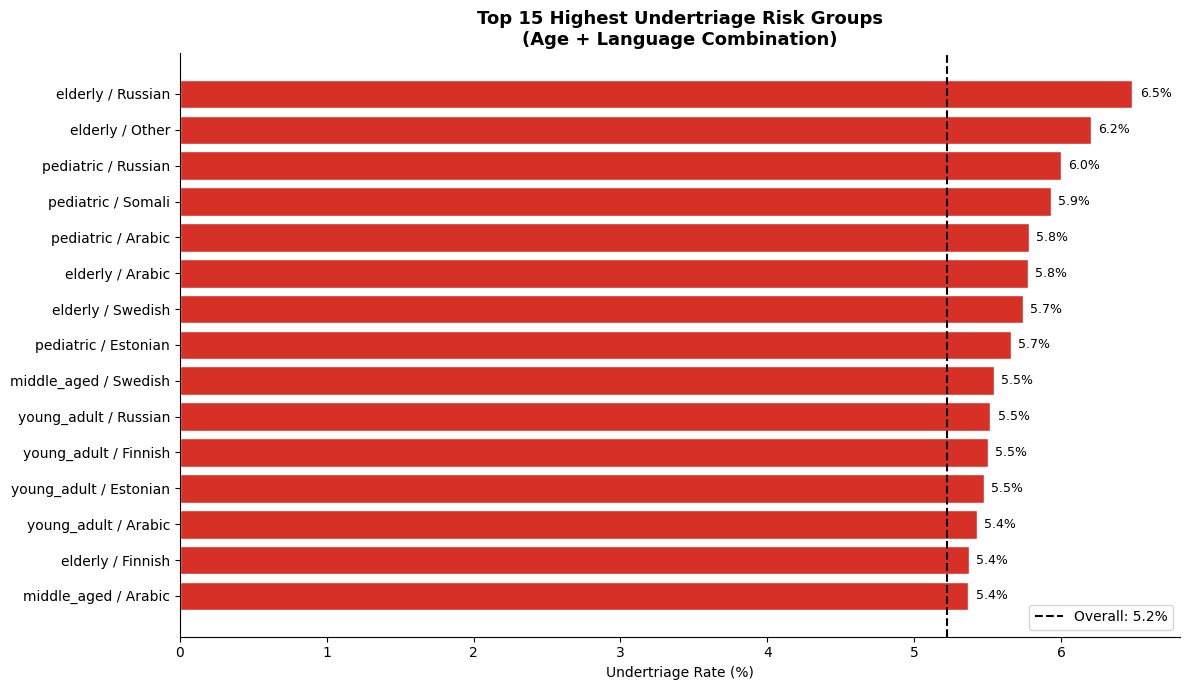

Compound risk analysis saved.

Top 10 highest risk combinations:
           risk_group  count     rate
    elderly / Russian   1542 6.485084
      elderly / Other   1064 6.203008
  pediatric / Russian    450 6.000000
   pediatric / Somali    236 5.932203
   pediatric / Arabic    346 5.780347
     elderly / Arabic   1022 5.772994
    elderly / Swedish   1743 5.737235
 pediatric / Estonian    389 5.655527
middle_aged / Swedish   2184 5.540293
young_adult / Russian   1649 5.518496


In [5]:
# ── Compound Risk Analysis ────────────────────────────────────────────

# Find highest risk combinations
train_demo['language_group'] = train_demo['language']
train_demo['risk_group'] = (train_demo['age_group'] + ' / ' + 
                             train_demo['language'])

compound = (train_demo.groupby('risk_group')['undertriaged']
            .agg(['mean', 'count'])
            .reset_index())
compound['rate'] = compound['mean'] * 100
compound = compound[compound['count'] >= 100]  # minimum sample size
compound = compound.sort_values('rate', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#d73027' if r > overall_rate else '#4575b4' 
          for r in compound['rate']]
bars = ax.barh(compound['risk_group'][::-1], 
               compound['rate'][::-1], 
               color=colors[::-1], edgecolor='white')
ax.axvline(x=overall_rate, color='black', linestyle='--', 
           linewidth=1.5, label=f'Overall: {overall_rate:.1f}%')
ax.set_title('Top 15 Highest Undertriage Risk Groups\n(Age + Language Combination)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Undertriage Rate (%)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, rate in zip(bars, compound['rate'][::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{rate:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/05_compound_risk.png', dpi=150, bbox_inches='tight')
plt.show()

# Save compound risk table
compound.to_csv('../outputs/bias_compound.csv', index=False)
print("Compound risk analysis saved.")
print("\nTop 10 highest risk combinations:")
print(compound[['risk_group', 'count', 'rate']].head(10).to_string(index=False))

### Headline Finding

**Elderly Russian-speaking patients face the highest undertriage risk at 6.5%** 
— nearly 25% above the overall rate of 5.2%. With 1,542 patients in this group, 
approximately 100 elderly Russian-speaking patients are being undertriaged.

The top risk combinations are:

| Group | Undertriage Rate | vs Overall |
|---|---|---|
| Elderly / Russian | 6.5% | +1.3% |
| Elderly / Other | 6.2% | +1.0% |
| Pediatric / Russian | 6.0% | +0.8% |
| Pediatric / Somali | 5.9% | +0.7% |
| Pediatric / Arabic | 5.8% | +0.6% |

**Clinical interpretation:** Language barriers compound age-related clinical 
vulnerability. Elderly patients already present atypically — their symptoms 
are often muted or masked by comorbidities — and communication difficulties 
further increase the risk that their true severity is underestimated at triage.

**Recommendation:** Triage protocols in multilingual Finnish EDs should 
incorporate structured interpreter access and mandatory vital sign completion 
for elderly patients presenting in non-Finnish languages.

---

## Limitations

- This analysis is conducted on **synthetic data** calibrated to published 
literature. Real-world undertriage patterns may differ in magnitude and direction.
- Our undertriage definition relies on model predictions as a proxy for 
"true" acuity — the model itself may carry biases from training data patterns.
- Sample sizes for some subgroups (e.g. pediatric / Somali, n=236) are small, 
limiting statistical confidence.
- Causality cannot be established — higher undertriage rates in certain groups 
may reflect unmeasured clinical factors rather than bias in triage assessment.

---

## Conclusion

This analysis demonstrates that demographic factors — particularly language 
minority status and advanced age — are associated with elevated undertriage 
rates in this synthetic Finnish ED dataset. The compounding effect of age and 
language creates identifiable high-risk subgroups that warrant targeted 
clinical intervention.

These findings, while based on synthetic data, are consistent with patterns 
reported in published Scandinavian emergency medicine literature and provide 
a framework for bias auditing that could be applied to real ED data.

**All bias results saved to:** `outputs/bias_language.csv`, `outputs/bias_insurance.csv`, 
`outputs/bias_sex.csv`, `outputs/bias_age.csv`, `outputs/bias_compound.csv`